In [73]:
from astropy.io import fits
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np

In [74]:
"homework10/M13_0001.fits"

'homework10/M13_0001.fits'

In [75]:
i = [
    "M13_0001.fits",
    "M13_0002.fits",
    "M13_0003.fits",
    "M13_0004.fits",
    "M13_0005.fits"
]
headers = []
data_list = []

for file_name in i:
    with fits.open(file_name) as hdul:
        header = hdul[0].header
        data = hdul[0].data
        data_list.append(data)
        print(f"Loaded {file_name}")

Loaded M13_0001.fits
Loaded M13_0002.fits
Loaded M13_0003.fits
Loaded M13_0004.fits
Loaded M13_0005.fits


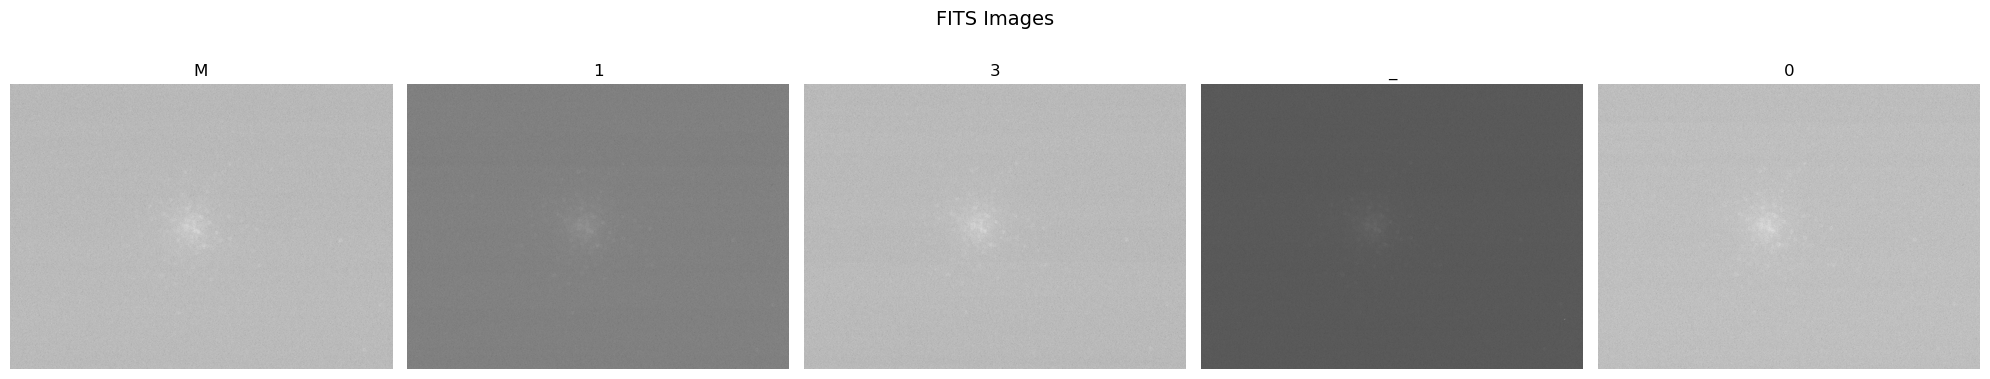

In [76]:
fig, axes=plt.subplots(1,5, figsize=(20,4))
                       
for i, (ax, data) in enumerate(zip(axes, data_list)):
    ax.imshow(data, cmap='gray', origin='lower')
    ax.set_title(file_name[i])
    ax.axis("off")
plt.suptitle( "FITS Images", y=1, fontsize=14)
plt.tight_layout()
plt.show()


# 1. Make a 1x5 subplots using plt.imshow() to plot each of the FITS files:

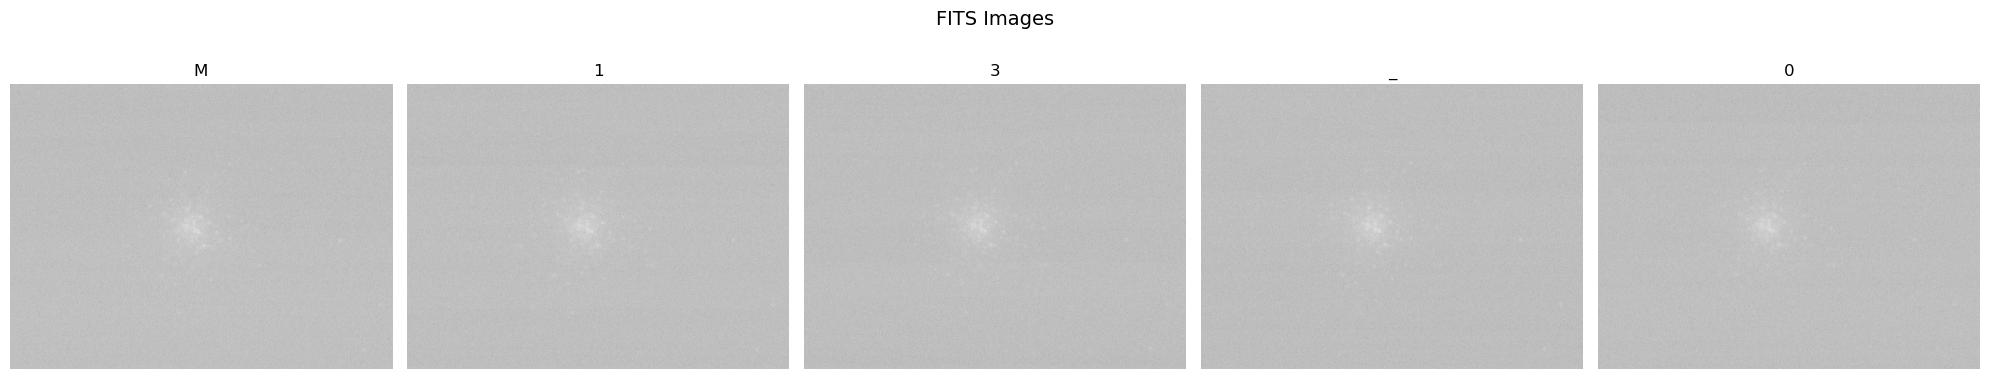

<Figure size 640x480 with 0 Axes>

In [77]:
# Replot the original five FITS images again but use the vmin and vmax values from the combined histogram.
vmin= min(data.min() for data in data_list)
vmax= min(data.max() for data in data_list)

fig, axes=plt.subplots(1,5, figsize=(20,4))
                       
for i, (ax, data) in enumerate(zip(axes, data_list)):
    im=    ax.imshow(data, cmap='gray', origin='lower',  vmin=vmin, vmax=vmax)
    ax.set_title(file_name[i])
    ax.axis("off")
plt.suptitle( "FITS Images", y=1, fontsize=14)
plt.tight_layout()
plt.show()

fig.colorbar(im, ax=axes.tolist(), label='huh')
plt.tight_layout()
plt.show()


In [78]:
# What differences do you notice in the images compared to the previous subplots?-  more visble

(array([2.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 6.00000e+00,
        1.40000e+01, 6.80000e+01, 3.04000e+02, 5.30000e+02, 1.06000e+03,
        1.51600e+03, 2.07600e+03, 3.01200e+03, 3.52700e+03, 5.21300e+03,
        7.95700e+03, 9.64200e+03, 1.40370e+04, 2.45320e+04, 5.85740e+04,
        1.58753e+05, 2.63168e+05, 3.45024e+05, 2.81448e+05, 1.50420e+05,
        7.23620e+04, 2.68620e+04, 9.70500e+03, 4.51400e+03, 1.98300e+03,
        9.11000e+02, 3.06000e+02, 1.10000e+02, 3.80000e+01, 4.00000e+00]),
 array([  0.  ,  13.62,  27.24,  40.86,  54.48,  68.1 ,  81.72,  95.34,
        108.96, 122.58, 136.2 , 149.82, 163.44, 177.06, 190.68, 204.3 ,
        217.92, 231.54, 245.16, 258.78, 272.4 , 286.02, 299.64, 313.26,
        326.88, 340.5 , 354.12, 367.74, 381.36, 394.

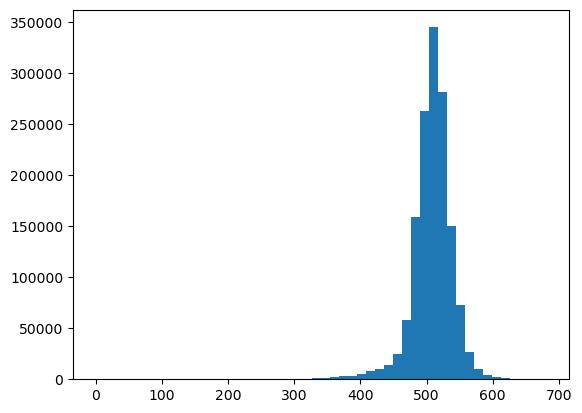

In [79]:
# 1. For each FITS file, make a histogram of pixel values:
plt.hist(data.ravel(), bins=50)

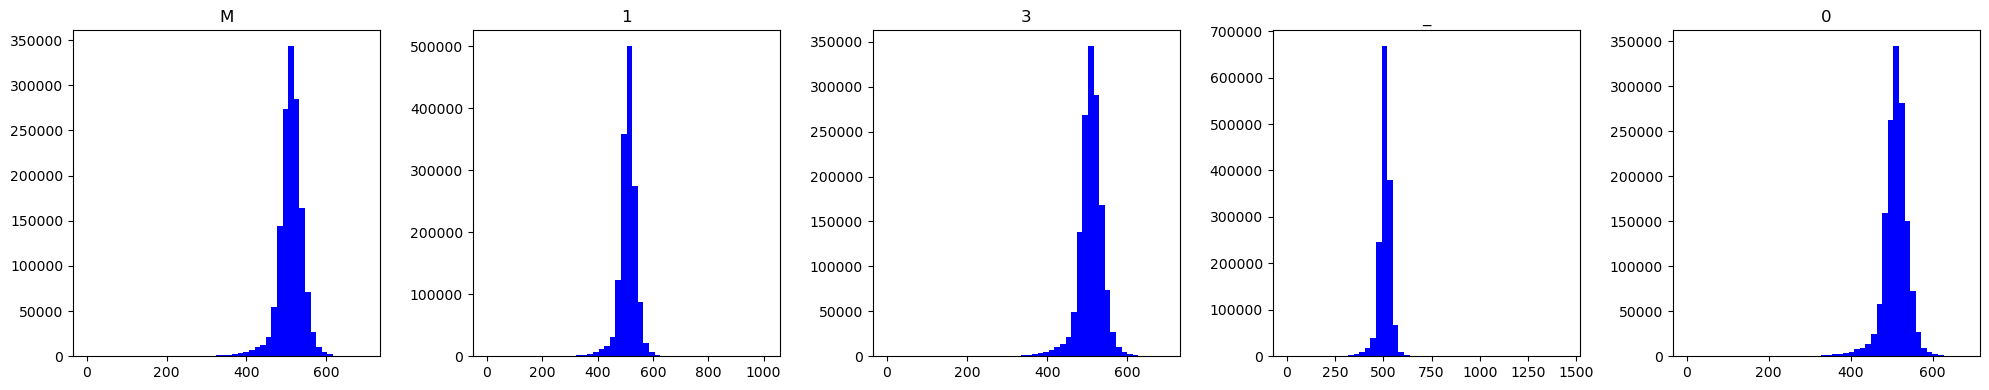

In [80]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, (ax, data) in enumerate(zip(axes, data_list)):
    ax.hist(data.ravel(), bins=50, color='blue')
    ax.set_title(file_name[i])
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()


In [81]:
# (a) not sure, haeven't seen this before
# (b) 50 bins where the data falls in
# (c) 
# (d) it's not spread out, data is clustered x val 
median = np.median(data.ravel())
mean = np.mean(data.ravel())
print('mean is',mean)
print('median is',median)
# (e) What is the median/mean pixel intensity value for each image?

mean is 508.7919920148099
median is 510.0


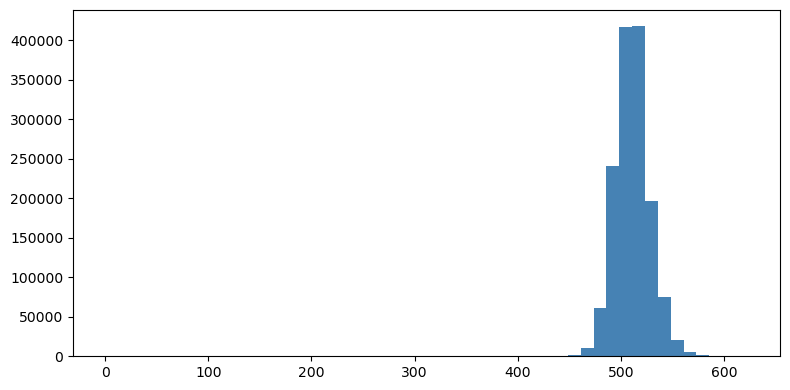

In [82]:
stacarr= np.array(data_list)
combcom=np.median(stacarr, axis=0)
fig, ax = plt.subplots(figsize=(8, 4))
counts, bin_edges, _= ax.hist(comb.ravel(), bins=50, color='steelblue')
plt.tight_layout()
plt.show()


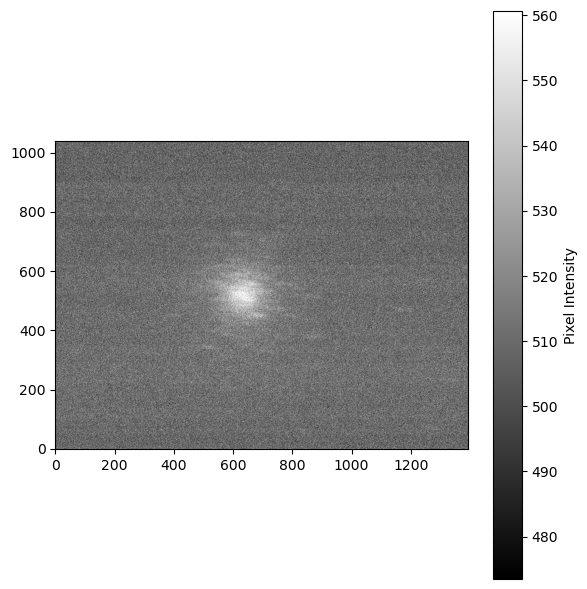

In [83]:
# vmin and vmax in your plt.imshow()
vmin = bin_edges[38]
vmax = bin_edges[45]
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(comb, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=ax, label="Pixel Intensity")
plt.tight_layout()
plt.show()
# it doesnt look right, so i searched what the prblem was, i think its bin edges
# comb=combined_edgeeeeeeee
# apparetnly i need to print out the max and min where the bulk of the data is and set that aas peak
# I SEE SOMETHIGN 

bin[ 0]  edge:     0.00  count: 2
bin[ 1]  edge:    12.46  count: 0
bin[ 2]  edge:    24.92  count: 0
bin[ 3]  edge:    37.38  count: 0
bin[ 4]  edge:    49.84  count: 0
bin[ 5]  edge:    62.30  count: 0
bin[ 6]  edge:    74.76  count: 0
bin[ 7]  edge:    87.22  count: 0
bin[ 8]  edge:    99.68  count: 0
bin[ 9]  edge:   112.14  count: 0
bin[10]  edge:   124.60  count: 0
bin[11]  edge:   137.06  count: 0
bin[12]  edge:   149.52  count: 0
bin[13]  edge:   161.98  count: 0
bin[14]  edge:   174.44  count: 1
bin[15]  edge:   186.90  count: 0
bin[16]  edge:   199.36  count: 0
bin[17]  edge:   211.82  count: 0
bin[18]  edge:   224.28  count: 0
bin[19]  edge:   236.74  count: 0
bin[20]  edge:   249.20  count: 0
bin[21]  edge:   261.66  count: 1
bin[22]  edge:   274.12  count: 1
bin[23]  edge:   286.58  count: 0
bin[24]  edge:   299.04  count: 0
bin[25]  edge:   311.50  count: 2
bin[26]  edge:   323.96  count: 0
bin[27]  edge:   336.42  count: 0
bin[28]  edge:   348.88  count: 0
bin[29]  edge:

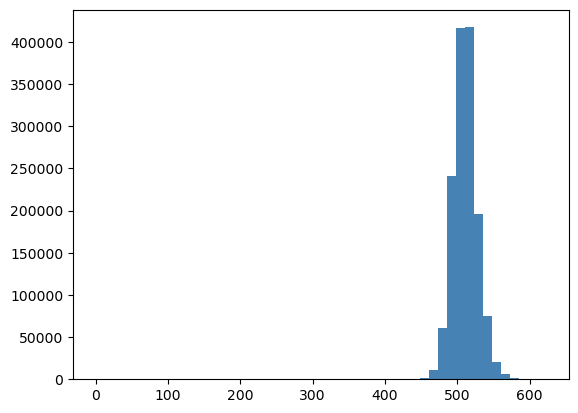

In [84]:
counts, bin_edges, _ = plt.hist(comb.ravel(), bins=50, color='steelblue')
for i, (edge, count) in enumerate(zip(bin_edges, counts)):
    print(f"bin[{i:2d}]  edge: {edge:8.2f}  count: {count:.0f}")



In [85]:
fits.writeto("csombined.fits", comb, overwrite=True)
